# Clustering Review

Use this notebook after running `scripts/07_clustering.py` to inspect UMAP structure, cluster sizes, sample mixing, and QC metric overlays.

In [4]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path("..").resolve()
CLUSTERING_DIR = REPO_ROOT / "results" / "clustering"
PLOTS_DIR = REPO_ROOT / "plots" / "clustering"

adata = ad.read_h5ad(CLUSTERING_DIR / "clustered.h5ad")
adata

AnnData object with n_obs × n_vars = 52876 × 3000
    obs: 'sample_id', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'qc_pass', 'leiden'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_correction', 'clustering', 'hvg', 'leiden', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

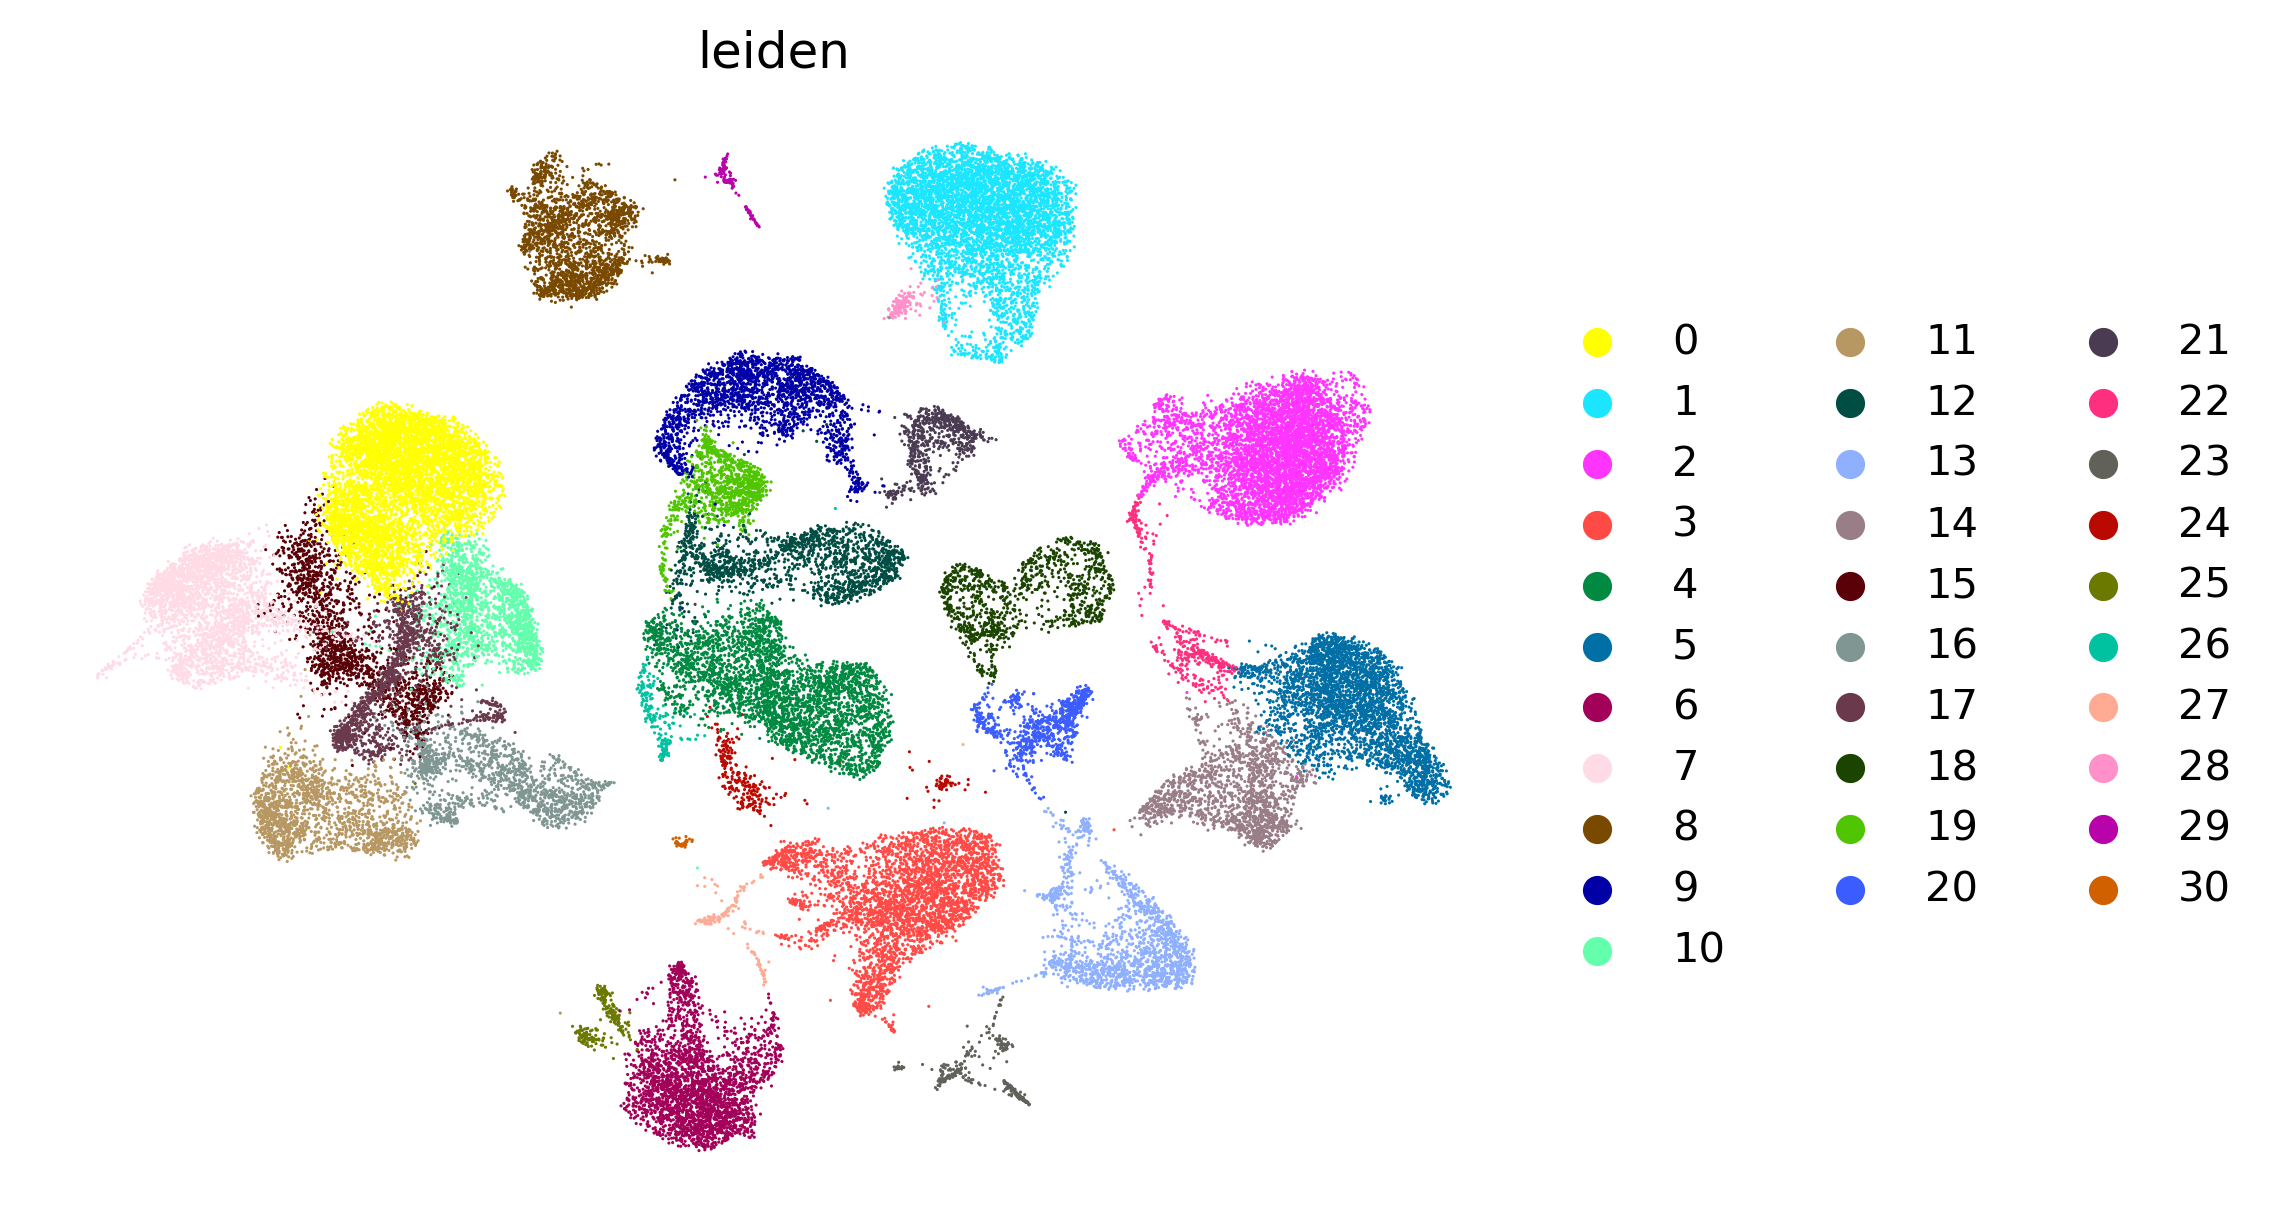

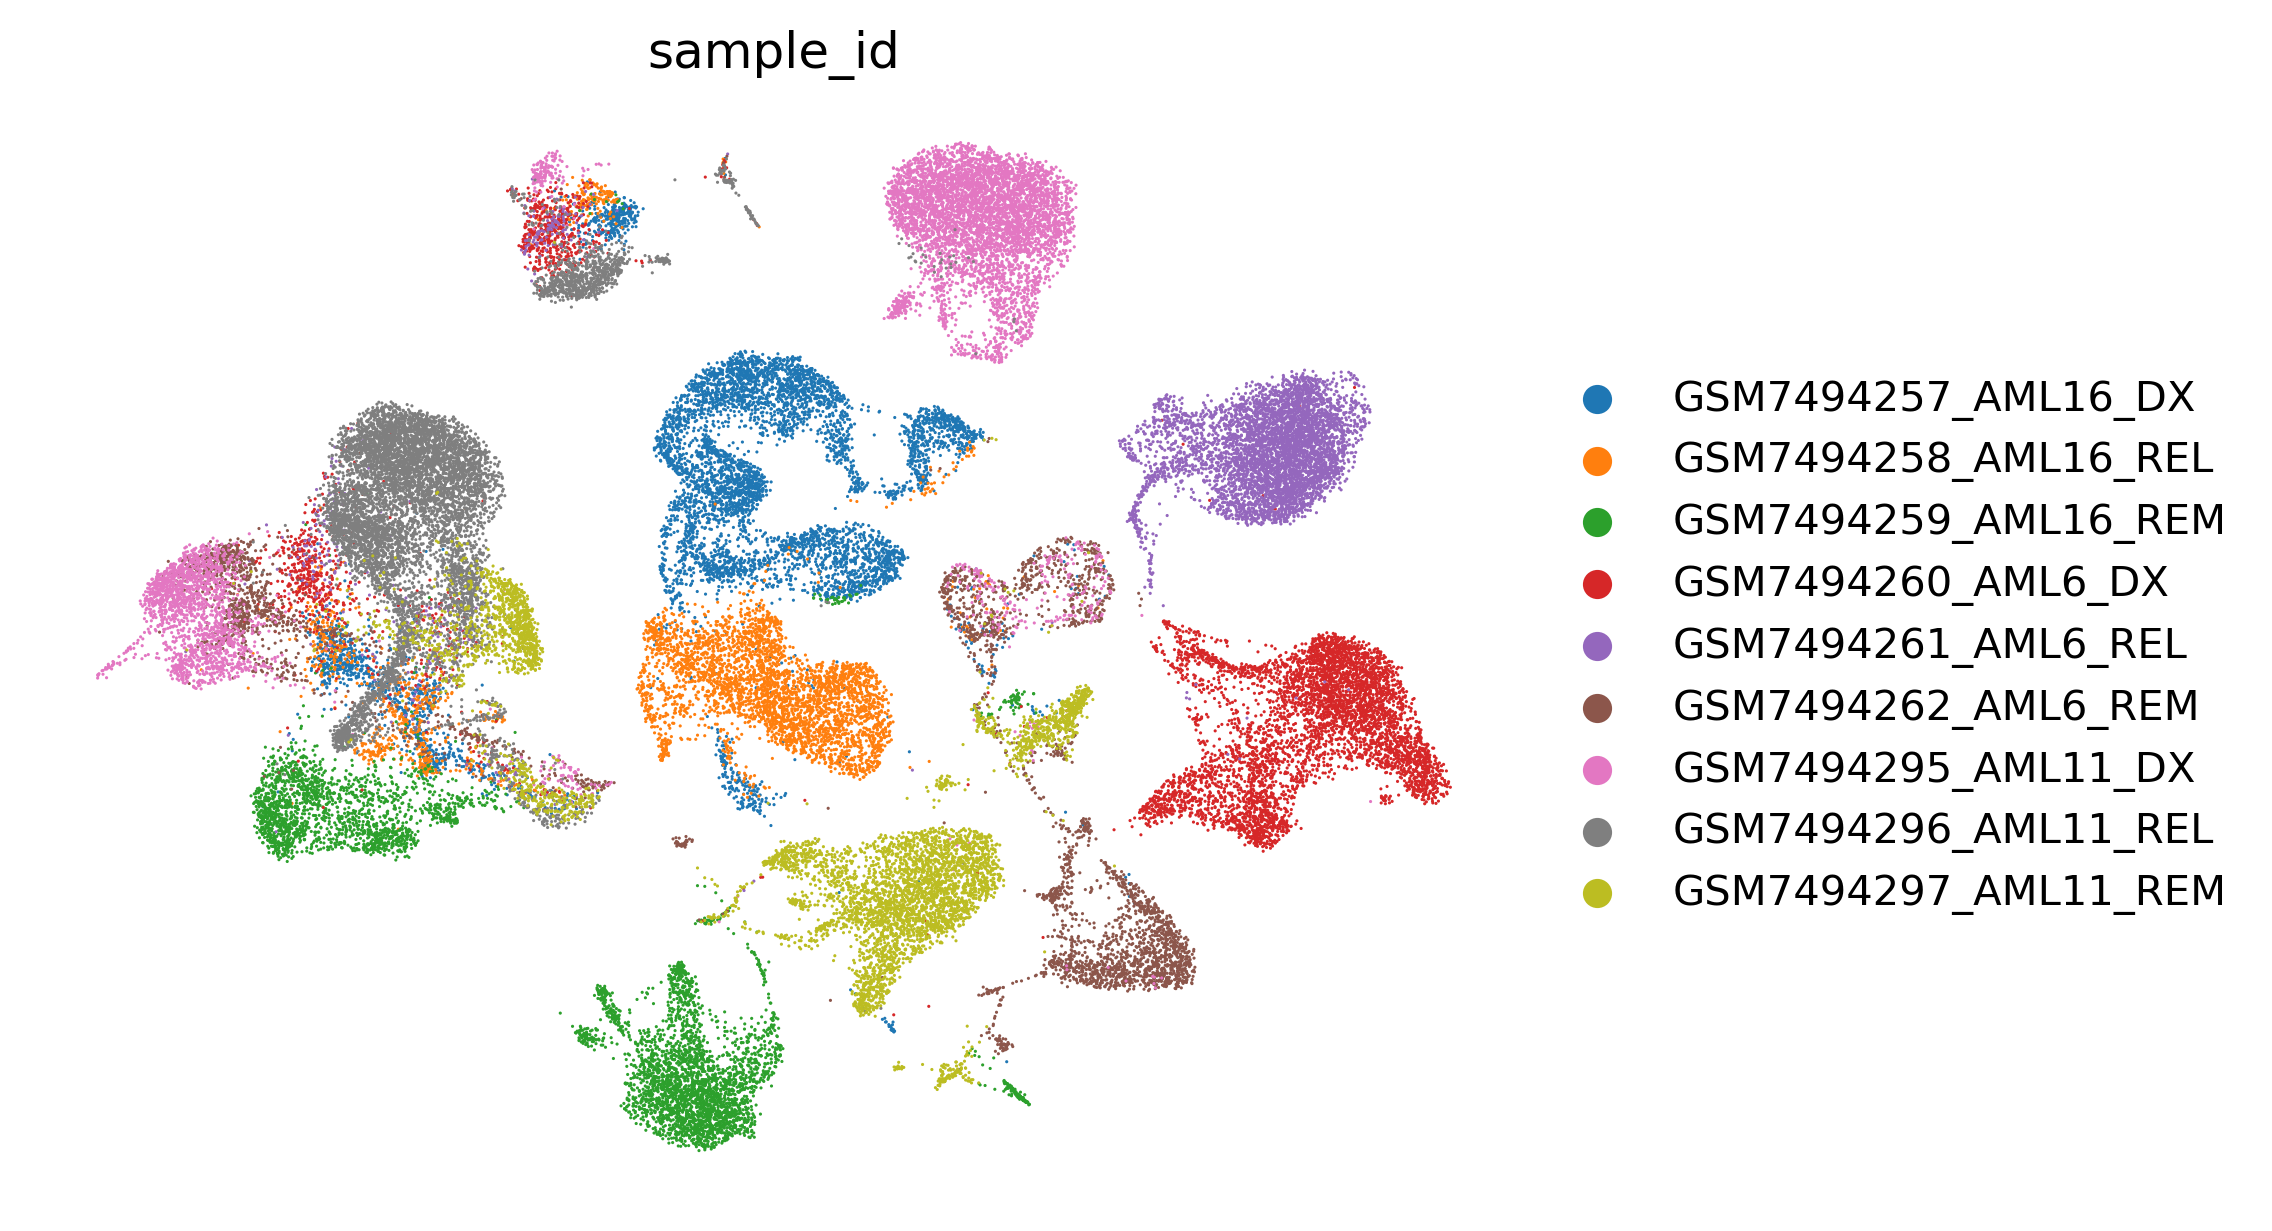

In [5]:
display(Image(filename=PLOTS_DIR / "umap_leiden.png"))
display(Image(filename=PLOTS_DIR / "umap_sample_id.png"))

In [6]:
cluster_counts = adata.obs["leiden"].value_counts().sort_index()
cluster_counts.to_frame("n_cells")

,n_cells
leiden,
0,5625
1,4990
2,4917
3,3360
4,3306
5,3299
6,2724
7,2658
8,2045


In [7]:
sample_counts = adata.obs["sample_id"].value_counts().sort_index()
sample_counts.to_frame("n_cells")

,n_cells
sample_id,
GSM7494257_AML16_DX,6747
GSM7494258_AML16_REL,4475
GSM7494259_AML16_REM,5153
GSM7494260_AML6_DX,6327
GSM7494261_AML6_REL,5358
GSM7494262_AML6_REM,3591
GSM7494295_AML11_DX,7335
GSM7494296_AML11_REL,8365
GSM7494297_AML11_REM,5525


In [8]:
cluster_by_sample = pd.crosstab(adata.obs["leiden"], adata.obs["sample_id"])
cluster_by_sample

sample_id,GSM7494257_AML16_DX,GSM7494258_AML16_REL,GSM7494259_AML16_REM,GSM7494260_AML6_DX,GSM7494261_AML6_REL,GSM7494262_AML6_REM,GSM7494295_AML11_DX,GSM7494296_AML11_REL,GSM7494297_AML11_REM
leiden,,,,,,,,,
0,3,4,2,33,44,5,1,5518,15
1,0,0,0,0,0,0,4959,31,0
2,0,0,0,10,4907,0,0,0,0
3,24,0,0,10,1,2,3,7,3313
4,37,3269,0,0,0,0,0,0,0
5,0,0,0,3295,3,0,1,0,0
6,0,0,2724,0,0,0,0,0,0
7,0,9,0,24,5,857,1753,3,7
8,302,172,10,473,111,2,143,831,1


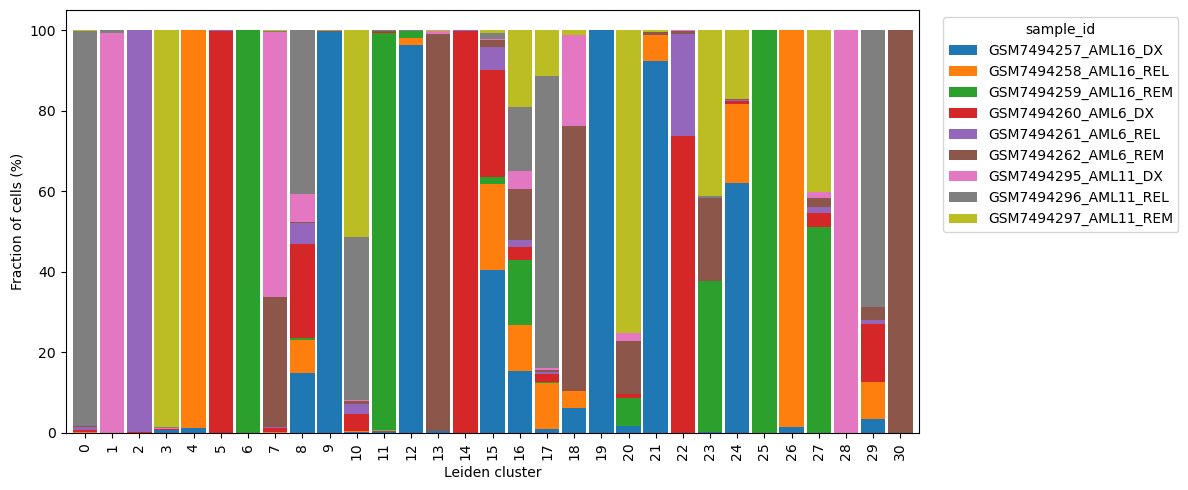

In [13]:
cluster_by_sample_fraction = cluster_by_sample.div(cluster_by_sample.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
cluster_by_sample_fraction.plot(kind="bar", stacked=True, ax=ax, width=0.9)
ax.set_xlabel("Leiden cluster")
ax.set_ylabel("Fraction of cells (%)")
ax.legend(title="sample_id", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

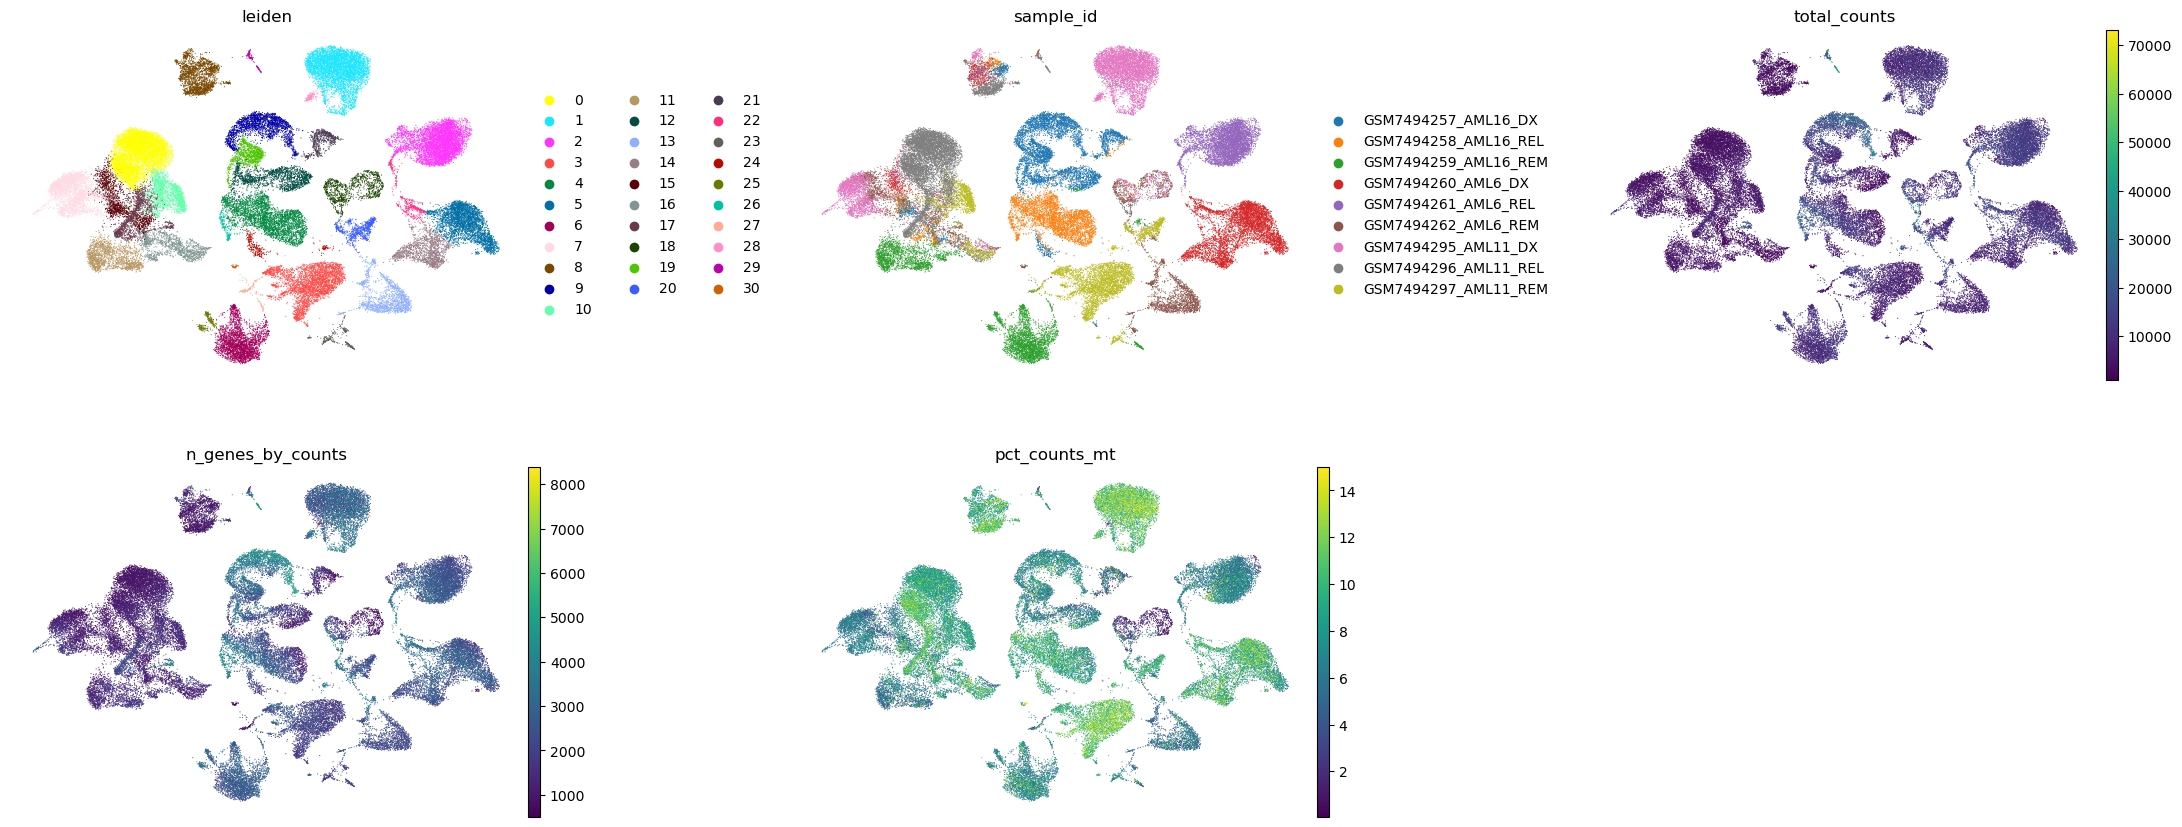

In [14]:
try:
    import scanpy as sc

    sc.pl.umap(
        adata,
        color=["leiden", "sample_id", "total_counts", "n_genes_by_counts", "pct_counts_mt"],
        frameon=False,
        wspace=0.4,
        ncols=3,
    )
except ImportError:
    print("Install scanpy to draw interactive UMAP overlays in this notebook.")

In [11]:
qc_by_cluster = adata.obs.groupby("leiden")[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].median()
qc_by_cluster

/tmp/ipykernel_103954/892086393.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qc_by_cluster = adata.obs.groupby("leiden")[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].median()


,total_counts,n_genes_by_counts,pct_counts_mt
leiden,,,
0,3792.0,958.0,8.240927
1,7767.5,2551.0,10.309598
2,11338.0,2331.0,5.709557
3,6196.0,1837.5,10.531585
4,8675.0,2280.0,8.076766
5,9040.0,2407.0,8.493951
6,9066.5,2560.0,6.156983
7,3858.0,1088.0,5.346415
8,2935.0,922.0,9.056886


Review notes:

- Clusters dominated by one sample may reflect biology, batch effects, or sample-specific quality issues.
- Clusters with unusually high `total_counts` or `n_genes_by_counts` may contain doublets.
- Clusters with high `pct_counts_mt` may contain stressed or dying cells.
- If the resolution is too coarse or too fine, rerun `scripts/07_clustering.py --resolution <value>`.